In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from datetime import datetime
import mlflow
from dotenv import load_dotenv
import os


In [7]:
df = pd.read_csv('data/train_df.csv')
try:
    df = df.drop(columns=['Unnamed: 0'])
except:
    pass
# Общая информация
print(df.info(show_counts=True)) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_17860\3295661960.py:1: DtypeWarning: Columns (6,9,12,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train_df.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13647309 entries, 0 to 13647308
Data columns (total 48 columns):
 #   Column                 Non-Null Count     Dtype  
---  ------                 --------------     -----  
 0   fecha_dato             13647309 non-null  object 
 1   ncodpers               13647309 non-null  int64  
 2   ind_empleado           13619575 non-null  object 
 3   pais_residencia        13619575 non-null  object 
 4   sexo                   13619505 non-null  object 
 5   age                    13647309 non-null  object 
 6   fecha_alta             13619575 non-null  object 
 7   ind_nuevo              13619575 non-null  float64
 8   antiguedad             13647309 non-null  object 
 9   indrel                 13619575 non-null  float64
 10  ult_fec_cli_1t         24793 non-null     object 
 11  indrel_1mes            13497528 non-null  object 
 12  tiprel_1mes            13497528 non-null  object 
 13  indresi                13619575 non-null  object 
 14  

1. Первичный анализ данных

In [8]:
with open('columns.txt', 'r', encoding='utf-8') as file:
    content = file.read().strip()  # Читаем содержимое и удаляем пробелы по краям
    items = [item.strip() for item in content.split(';') if item.strip()]

In [9]:
cool_names_dict = dict(zip(list(df.columns),items))

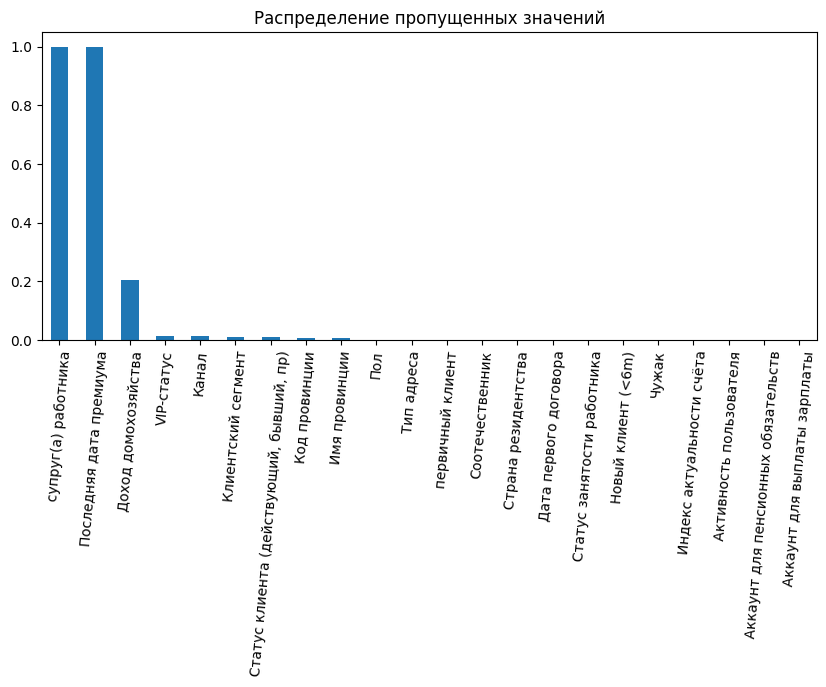

In [10]:
# Пропуски в данных
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing>0]
labels = missing.index.tolist()
cool_labels =[cool_names_dict[label] for label in labels]
missing[missing > 0].plot(kind='bar', figsize=(10, 4))
#set x axis labels to labels list
plt.xticks(range(len(cool_labels)), cool_labels, rotation=85)
plt.title('Распределение пропущенных значений')
plt.show()

Вывод: Пропусков достаточно мало, при это с большим отрывом лидирует кчественные признак супруг(а) работника и последняя дата премиума. Тройку лидеров занимает Доход домохозяйства. В первых двух случаях процент пропусков настолько велик, что их смело можно игнорировать. А вот с третьей придётся что-то придумать для заполнения пропусков.

1.1 Анализ верменных данных

In [11]:
# Преобразование в datetime с обработкой ошибок
df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')
df['ult_fec_cli_1t'] = pd.to_datetime(df['fecha_alta'], errors='coerce')

# 1. Анализ временного диапазона и пропусков
for time_col in ['fecha_alta', 'ult_fec_cli_1t']:
    print(f"Основная информация о датах /{cool_names_dict[time_col]}/:")
    print(f"Минимальная дата: {df[time_col].min().strftime('%Y-%m-%d')}")
    print(f"Максимальная дата: {df[time_col].max().strftime('%Y-%m-%d')}")
    print(f"Пропущенные значения: {df[time_col].isna().sum()} ({df[time_col].isna().mean():.1%})")

Основная информация о датах /Дата первого договора/:
Минимальная дата: 1995-01-16
Максимальная дата: 2016-05-31
Пропущенные значения: 27734 (0.2%)
Основная информация о датах /Последняя дата премиума/:
Минимальная дата: 1995-01-16
Максимальная дата: 2016-05-31
Пропущенные значения: 27734 (0.2%)


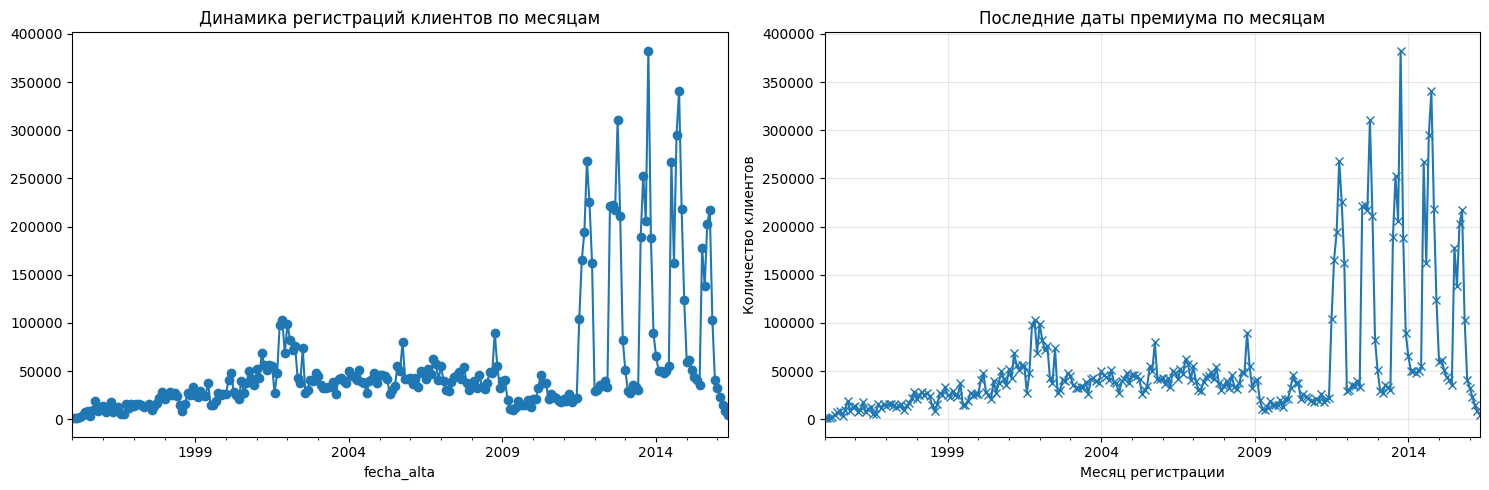

In [12]:
# 2. Визуализация распределения по месяцам
fig, ax = plt.subplots(1,2, figsize=(15, 5))
df['fecha_alta'].dt.to_period('M').value_counts().sort_index().plot(
    kind='line', 
    marker='o',
    title='Динамика регистраций клиентов по месяцам',
    ax=ax[0]
)
df['ult_fec_cli_1t'].dt.to_period('M').value_counts().sort_index().plot(
    kind='line', 
    marker='x',
    title='Последние даты премиума по месяцам',
    ax=ax[1]
)
plt.xlabel('Месяц регистрации')
plt.ylabel('Количество клиентов')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
def create_time_cohorts(series, max_cohorts=30):
    """
    Разделяет временной ряд на когорты с примерно равным количеством элементов
    
    Параметры:
        series (pd.Series): Временной ряд с датами
        max_cohorts (int): Максимальное количество когорт
    
    Возвращает:
        pd.Series: Метки когорт для каждого наблюдения
    """
    # Преобразуем даты в числовой формат (дни с минимальной даты)
    base_date = series.min()
    days_since = (series - base_date).dt.days
    
    # Автоматический подбор количества когорт
    n_cohorts = min(max_cohorts, len(series.unique()))
    
    # Разбиение на когорты с проверкой дубликатов
    try:
        cohorts = pd.qcut(
            days_since,
            q=n_cohorts,
            precision=0,
            duplicates='drop'
        )
    except ValueError:
        # Если невозможно разбить на запрошенное количество когорт
        n_cohorts = len(series.unique())
        cohorts = pd.qcut(
            days_since,
            q=n_cohorts,
            precision=0,
            duplicates='drop'
        )
    
    # Преобразуем обратно в даты
    cohort_ranges = cohorts.apply(
        lambda x: pd.Interval(
            left=base_date + pd.Timedelta(days=x.left),
            right=base_date + pd.Timedelta(days=x.right),
            closed='right'
        )
    )
    
    return cohort_ranges

In [14]:
for time_col in ['fecha_alta', 'ult_fec_cli_1t']:
    df[time_col] = create_time_cohorts(df[time_col], max_cohorts=30)

1.2. Анализ количественных признаков

In [15]:
quantitative_cols = ['age','antiguedad','renta']
for col in quantitative_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
def analyze_numerical_features(df, namer, sample_size=10000):
    """
    Анализирует количественные признаки с автоматическим подбором визуализаций
    """
   
    # Сэмплирование данных для больших датасетов
    df_sample = df.sample(min(sample_size, len(df))) if len(df) > sample_size else df
    
    # Настройка стиля графиков
    plt.style.use('seaborn-v0_8-poster')
    sns.set_palette("husl")
    numeric_cols = [col for col in df.columns]
    # Анализ каждого признака
    for col in numeric_cols:
        print(f"\nАнализ признака: {namer[col]}")
        print("="*40)
        
        # Статистики
        data = np.array(df_sample[col].dropna())
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        
        print(f"Количество уникальных значений: { len(np.unique(data))}")
        print(f"Пропущенные значения: {df[col].isna().sum()}")
        print(f"Среднее: {data.mean():.2f}")
        print(f"Скошенность: {skewness:.2f}")
        print(f"Эксцесс: {kurtosis:.2f}")
        print(f"Описание:\n{df_sample[col].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])}")
        
        # Создаем фигуру
        plt.figure(figsize=(16, 6))
        plt.suptitle(f'Анализ признака: {namer[col]}', y=1.02)
        
        # Гистограмма и плотность распределения
        plt.subplot(1, 3, 1)
        sns.histplot(data, kde=True)
        plt.title(f'Распределение ({len(np.unique(data))} unique)')
        plt.xlabel('')
        
        # Боксплот
        plt.subplot(1, 3, 2)
        sns.boxplot(x=data)
        plt.title(f'Выбросы (skew: {skewness:.2f})')
        plt.xlabel('')
        
        # Q-Q plot
        plt.subplot(1, 3, 3)
        stats.probplot(data, dist="norm", plot=plt)
        plt.title('Q-Q Plot')
        
        plt.tight_layout()
        plt.show()
    


Анализ признака: Возраст
Количество уникальных значений: 104
Пропущенные значения: 27734
Среднее: 40.08
Скошенность: 0.85
Эксцесс: 0.31
Описание:
count    9986.000000
mean       40.081214
std        17.345005
min         3.000000
25%        24.000000
50%        38.000000
75%        50.000000
95%        73.000000
99%        90.000000
max       113.000000
Name: age, dtype: float64


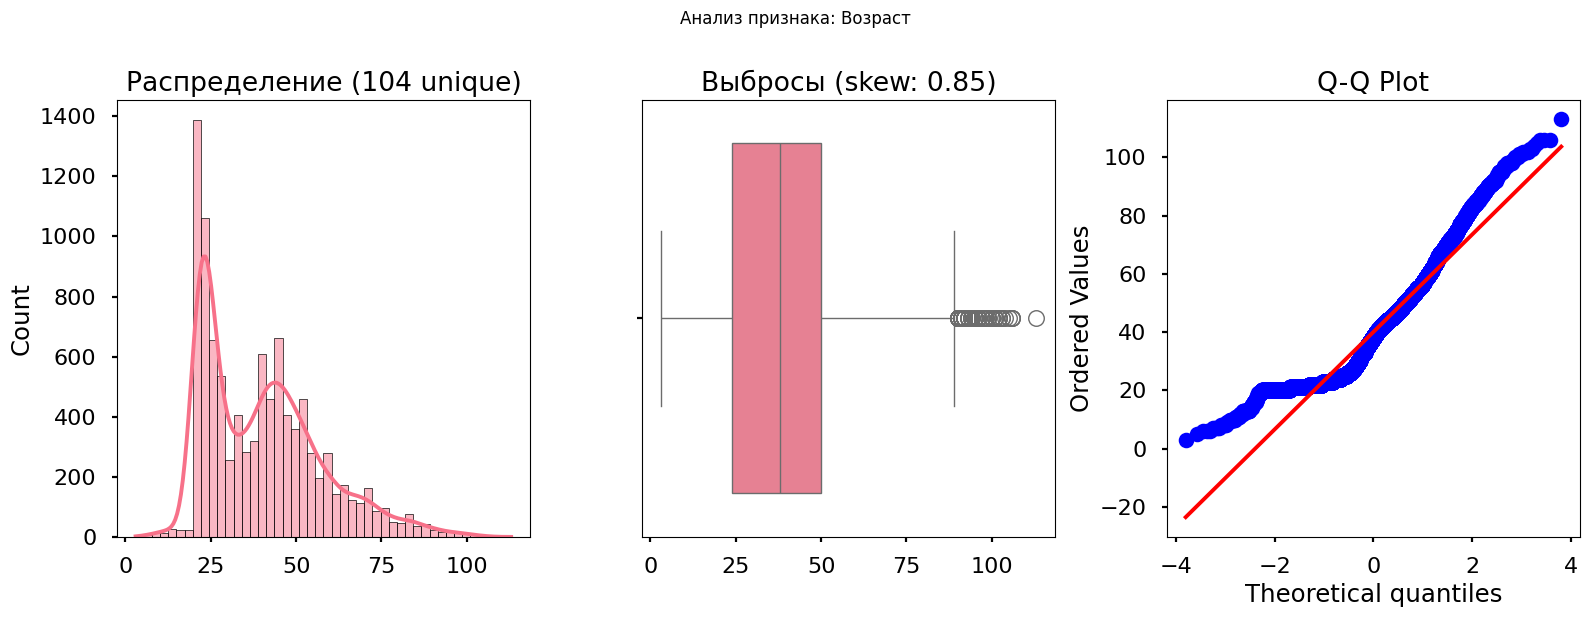


Анализ признака: Стаж клиента (в месяцах)
Количество уникальных значений: 250
Пропущенные значения: 27734
Среднее: 79.29
Скошенность: 0.65
Эксцесс: -0.88
Описание:
count    9986.000000
mean       79.289605
std        66.224300
min         0.000000
25%        23.000000
50%        50.000000
75%       135.000000
95%       201.000000
99%       231.000000
max       250.000000
Name: antiguedad, dtype: float64


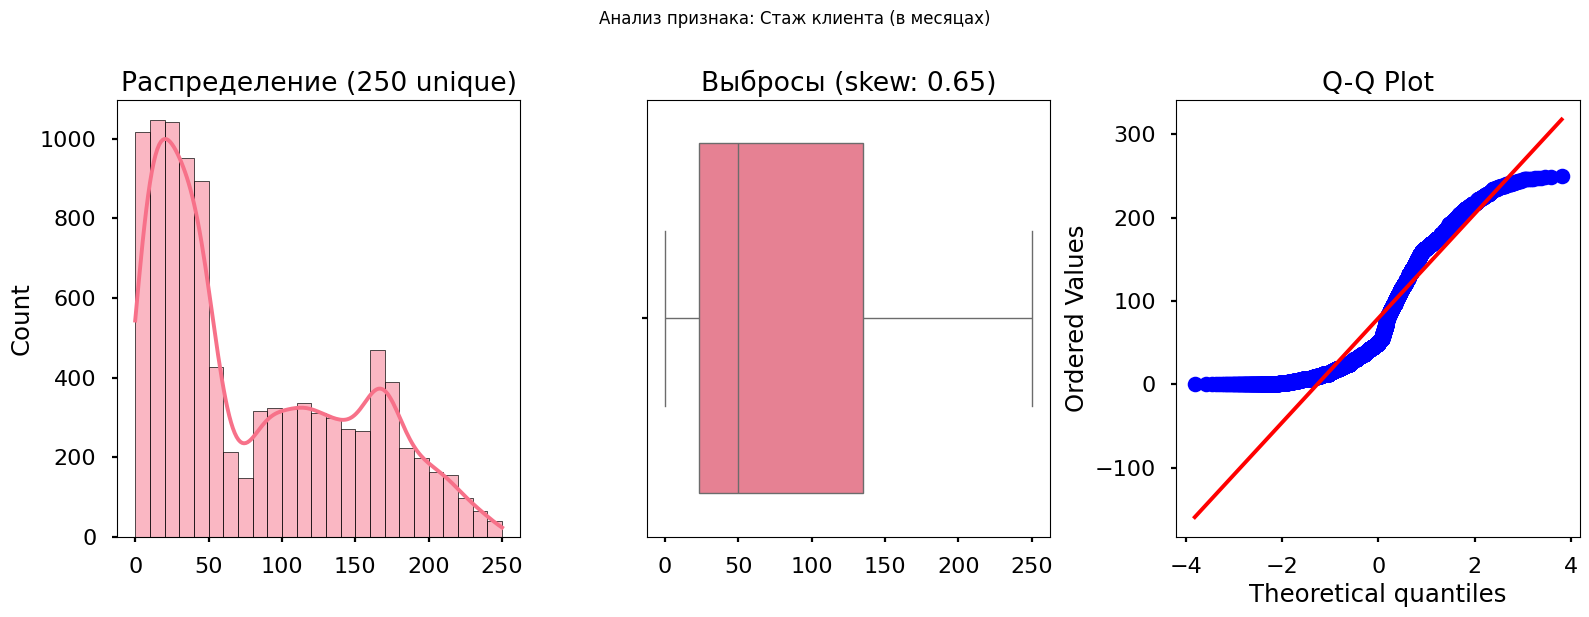


Анализ признака: Доход домохозяйства
Количество уникальных значений: 7832
Пропущенные значения: 2794375
Среднее: 131613.78
Скошенность: 12.91
Эксцесс: 347.62
Описание:
count    7.924000e+03
mean     1.316138e+05
std      1.363840e+05
min      1.173066e+04
25%      6.789691e+04
50%      1.018693e+05
75%      1.558465e+05
95%      3.072535e+05
99%      5.694907e+05
max      5.046790e+06
Name: renta, dtype: float64


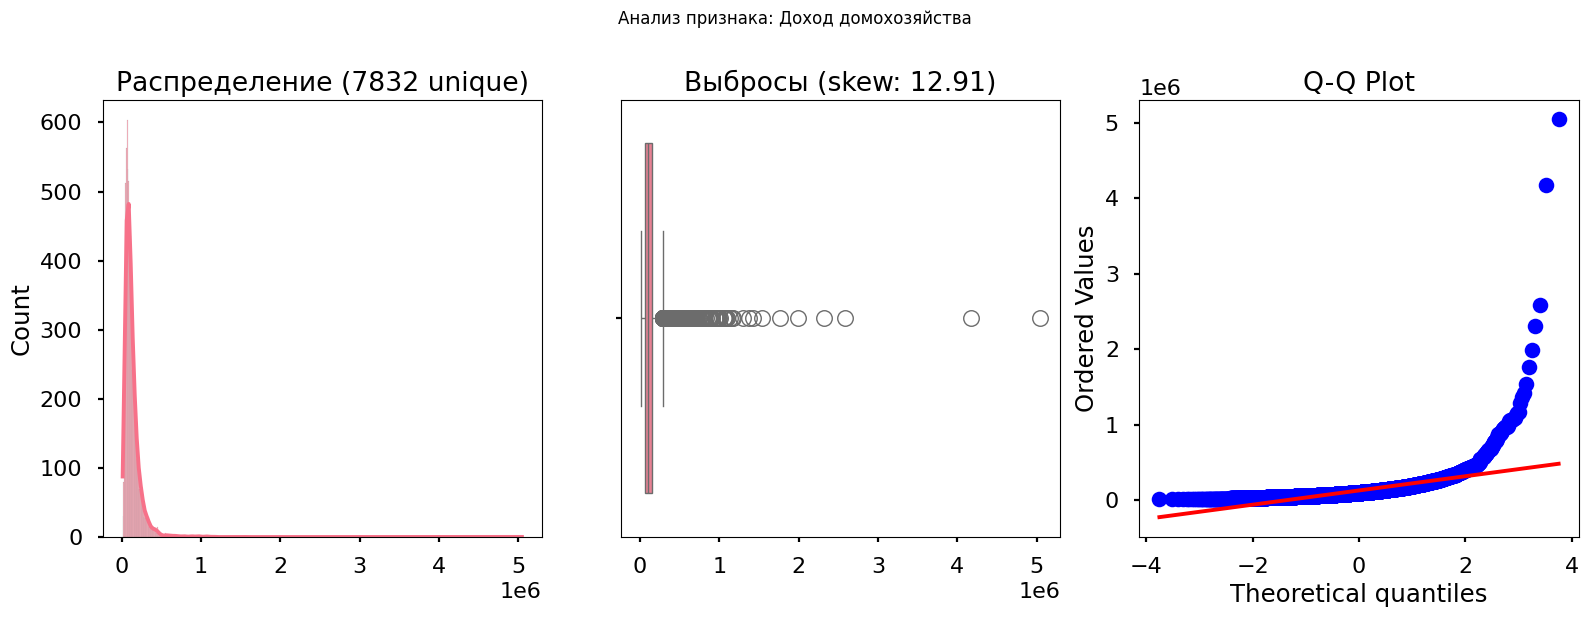

In [17]:
analyze_numerical_features(df[quantitative_cols], cool_names_dict)

*Выводы*
1) По возрасту очень много выбросов, настораживают клиенты с возрастом 0 и более 100 лет. Тут понадобится поработать с выбросами.
2) Стаж клиента в месяцах более скучен, и имеет два выраженных пика: 25 и 170 месяцев. Но в целом, ничего безумного в данных нет, но конечно их лучше будет подвергнуть нормализации.
3) С доходом семей всё проще, в основном население бедное и есть счётное чилсо ультра-богатых, которых модели лучше не показывать, так как с этми людьми надо работать индивидуально, а не по "закону больших чисел".

1.3 Анализ категориальных признаков

In [18]:
products=['ind_ahor_fin_ult1',
'ind_aval_fin_ult1',
'ind_cco_fin_ult1',
'ind_cder_fin_ult1',
'ind_cno_fin_ult1',
'ind_ctju_fin_ult1',
'ind_ctma_fin_ult1',
'ind_ctop_fin_ult1',
'ind_ctpp_fin_ult1',
'ind_deco_fin_ult1',
'ind_deme_fin_ult1',
'ind_dela_fin_ult1',
'ind_ecue_fin_ult1',
'ind_fond_fin_ult1',
'ind_hip_fin_ult1',
'ind_plan_fin_ult1',
'ind_pres_fin_ult1',
'ind_reca_fin_ult1',
'ind_tjcr_fin_ult1',
'ind_valo_fin_ult1',
'ind_viv_fin_ult1',
'ind_nomina_ult1',
'ind_nom_pens_ult1',
'ind_recibo_ult1']


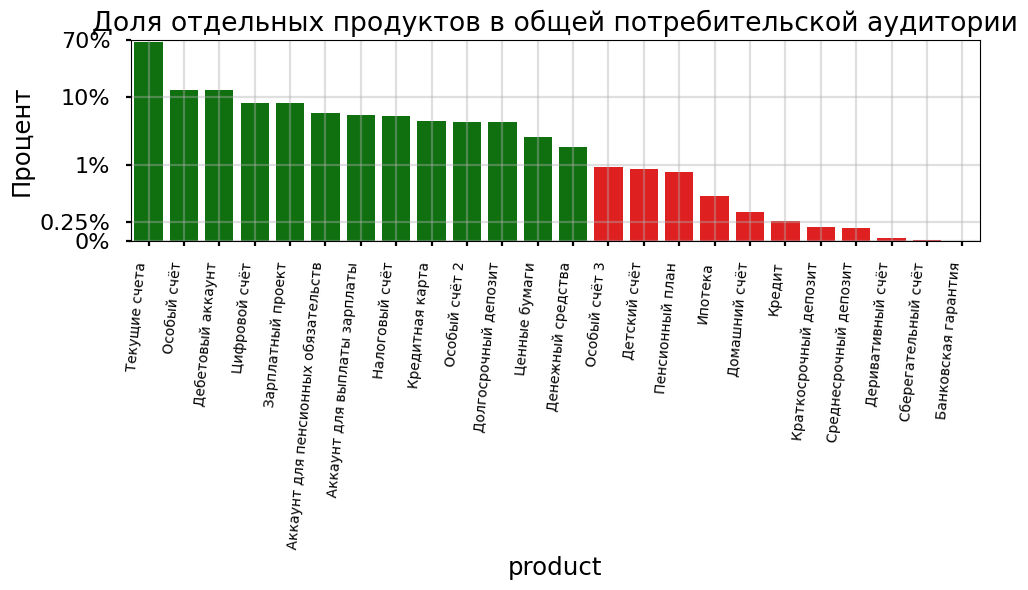

In [19]:
d = df[products].mean()*100
sorted_df = d.to_frame('Доля').sort_values(by='Доля', ascending=False)
p_list = sorted_df.index.tolist()

# Создаем DataFrame для Seaborn
plot_df = sorted_df.reset_index().rename(columns={'index': 'product'})
colors = ['red' if x < 1 else 'green' for x in plot_df['Доля']]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='product',
    y='Доля',
    data=plot_df,
    palette=colors,
    hue = 'product',
    order=plot_df['product']  # Сохраняем сортировку
)

# Настраиваем подписи и оформление
plt.xticks(
    range(len(p_list)),
    [cool_names_dict[x] for x in p_list],
    rotation=85,
    ha='right',
    size=10
)
plt.ylabel('Процент')
plt.yscale('symlog', linthresh=1)
plt.yticks([0, 0.25, 1, 10, 70], ['0%','0.25%', '1%', '10%', '70%'])
plt.title('Доля отдельных продуктов в общей потребительской аудитории')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Мы видим, что подавляющее большинство продуктов никому не нужны. Только Особый, Текуший счёт и дебетовый аккаунт пробили порог в 10% клиентов.
Значительная часть продуктов вообще есть менее чем у 1% клиентов. В общем создаётся впечатление, продуктовая политика банка не оптимальна. Но так как мы не знаем на чём именно он зарабатывает, на массовом сегменте или на уникальных разовых продажах, то нельзя сделать каких-то выводов.



In [20]:
# Оставим только продукты, преодолевшие порог статистической значимости в 5%
products =d[d>5].to_frame('Доля').sort_values(by='Доля', ascending=False).index.tolist()
# Выберем продукты-аутосайдеры, которые купили менее 0,25% клиентов
outsiders = d[d<0.25].to_frame('Доля').sort_values(by='Доля', ascending=False).index.tolist()


In [21]:
one_month_data = df[df['fecha_dato']=='2016-05-28']

In [22]:

def make_heatmap(df, f, dict, products):
    data = df[products+[f]].copy()
    # Группировка и агрегация данных
    heatmap_data = data.groupby(f).mean().T * 100  # Процентное представление

    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=.5,
        cbar_kws={'label': 'Доля приобретенных продуктов (%)'}
    )

    plt.title(f'Распределение продуктов по категориям {dict[f]}')
    plt.xlabel(dict[f])
    plt.ylabel('Список продуктов')
    plt.xticks(rotation=0, size=10)
    plt.tight_layout()
    plt.yticks(range(len(products)), [dict[x] for x in products], size=10)
    plt.show()

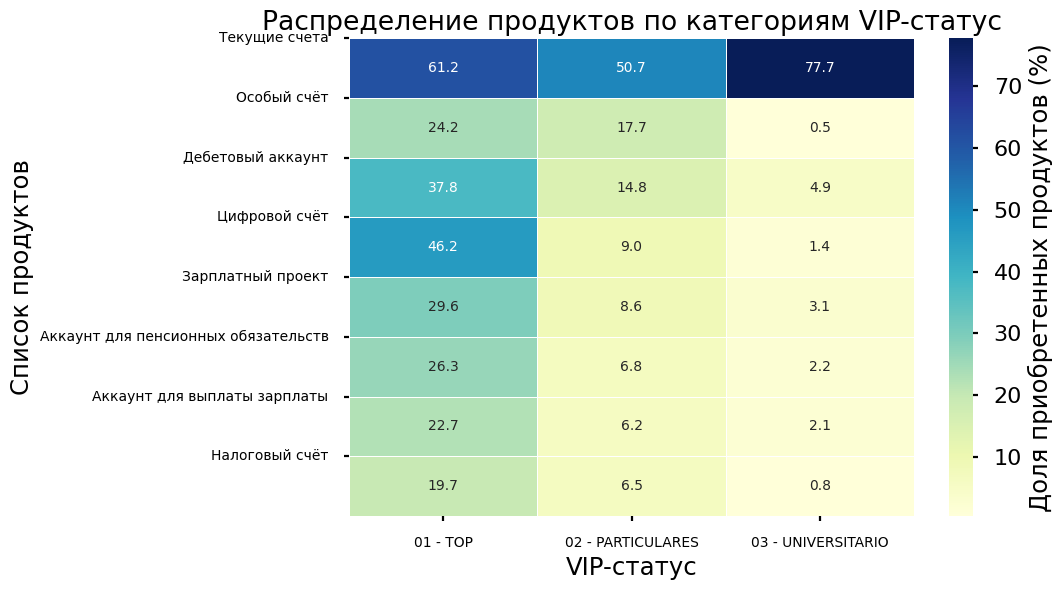

In [23]:
sub = df[df['fecha_dato']=='2015-12-28']
one_month_data = sub[products+['segmento']].copy()
make_heatmap(one_month_data, f='segmento', dict=cool_names_dict, products=products)

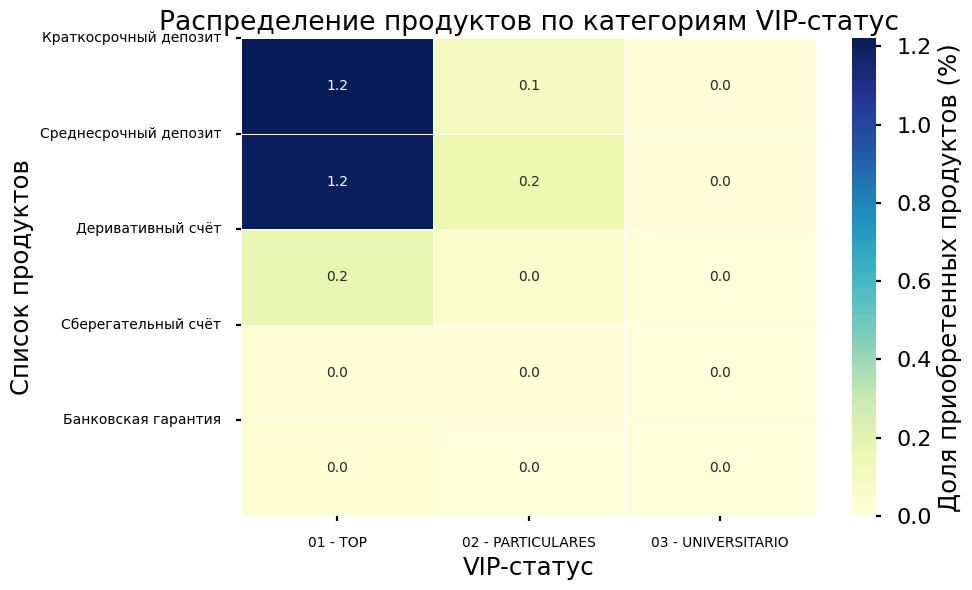

In [24]:
make_heatmap(sub, f='segmento', dict=cool_names_dict, products=outsiders)

In [25]:

for c in df.columns:
    print(cool_names_dict[c]+"*"*10)
    print(sub[c].value_counts(normalize=True))

Колонка для разделения таблицы**********
fecha_dato
2015-12-28    1.0
Name: proportion, dtype: float64
Идентификатор пользователя**********
ncodpers
1400556    0.000001
1017818    0.000001
1017819    0.000001
1017820    0.000001
1017821    0.000001
             ...   
298344     0.000001
1017829    0.000001
1017827    0.000001
1017825    0.000001
1017824    0.000001
Name: proportion, Length: 912021, dtype: float64
Статус занятости работника**********
ind_empleado
N    0.999430
B    0.000240
F    0.000167
A    0.000162
S    0.000001
Name: proportion, dtype: float64
Страна резидентства**********
pais_residencia
ES    0.995639
FR    0.000343
AR    0.000318
DE    0.000306
GB    0.000306
        ...   
BZ    0.000001
GM    0.000001
CD    0.000001
KZ    0.000001
JM    0.000001
Name: proportion, Length: 117, dtype: float64
Пол**********
sexo
V    0.541675
H    0.458325
Name: proportion, dtype: float64
Возраст**********
age
24.0     0.055350
23.0     0.055136
22.0     0.053448
21.0     0.05267

*Выводы*

1. Демография клиентов:
География: 99.56% клиентов — резиденты Испании, с доминированием Мадрида (32.3%) и Барселоны (9.59%).
Возраст: Основная аудитория — молодые люди 20-24 лет. Присутствуют аномалии (возраст >100 лет), требующие проверки данных.
Пол: Небольшой перевес в сторону женщин (54.17% vs 45.83% мужчин).
2. Клиентская активность:
Стаж: 88.6% клиентов — не новые (стаж >6 месяцев). Пики активности приходятся на 2015-2016 гг.
Активность: 57.8% клиентов неактивны — критичный показатель для бизнеса.
Каналы привлечения: 73% клиентов приходят через 3 канала (KHE, KAT, KFC). Остальные 157 каналов — маргинальны.
3. Финансовые продукты:
Доминирующие продукты:
Текущие счета (61.08%)
Дебетовые аккаунты (11.77%)
Низкий спрос:
Ипотека (0.5%)
Пенсионные планы (0.8%)
Краткосрочные депозиты (0.1%)
Аномалии: Нулевая доля VIP-продуктов (сегмент "01 - TOP" — 3.79%).
4. Данные и качество:
Выбросы: Возрастные аномалии (до 163 лет), отрицательный стаж (-999999).
Монохромность данных:
99.94% клиентов имеют статус занятости "N"
99.75% счетов активны (indfall)
99.56% клиентов — соотечественники (indresi)

Видимо придётся на этапе предобработки:
1) Устранить пропуски в данных
2) Устранить аномалии
3) Сгруппировать маргинальные категории в раздел "прочие".
4) Избавится от мало-информативных признаков.

1.4 Анализ дубликатов

In [26]:
len(df)- len(df.drop_duplicates())

0

Явные дубликаты не обранружены.

In [27]:
# Проверка соответствия кодов провинций и их названий
prov_mapping = df[['cod_prov', 'nomprov']].drop_duplicates().sort_values('cod_prov')
print(prov_mapping)

      cod_prov                 nomprov
1489       1.0                   ALAVA
151        2.0                ALBACETE
52         3.0                ALICANTE
292        4.0                 ALMERIA
26         5.0                   AVILA
159        6.0                 BADAJOZ
68         7.0          BALEARS, ILLES
15         8.0               BARCELONA
22         9.0                  BURGOS
9         10.0                 CACERES
229       11.0                   CADIZ
137       12.0               CASTELLON
1         13.0             CIUDAD REAL
538       14.0                 CORDOBA
80        15.0               CORUÑA, A
107       16.0                  CUENCA
11        17.0                  GIRONA
732       18.0                 GRANADA
325       19.0             GUADALAJARA
8         20.0                GIPUZKOA
646       21.0                  HUELVA
23        22.0                  HUESCA
94        23.0                    JAEN
6         24.0                    LEON
37        25.0           

Неявных дубликатов в названиях регионов не обнаружено. Но для нужд моделей целесообразно оставить только коды. Естественно после объединения маргинальных категорий.

In [28]:
# Анализ похожих каналов
from difflib import get_close_matches

# Convert all elements to strings, replacing NaN with an empty string or any other placeholder
channels = df['canal_entrada'].dropna().astype(str).unique()

for channel in channels:
    matches = get_close_matches(channel, channels, n=2, cutoff=0.8)
    if len(matches) > 1:
        # Your logic here
        print(matches)


Неяных дубликатов в названии каналов тоже нет.  
Остальные колонки содержат данные, где появление неявных дубликатов невозможно.

In [29]:
df['ncodpers']

0           1375586
1           1050611
2           1050612
3           1050613
4           1050614
             ...   
13647304    1166765
13647305    1166764
13647306    1166763
13647307    1166789
13647308    1550586
Name: ncodpers, Length: 13647309, dtype: int64

In [30]:
one_man = df[df['ncodpers']==1375586]

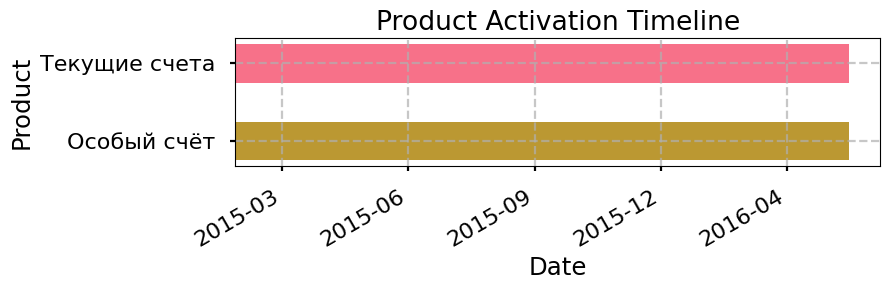

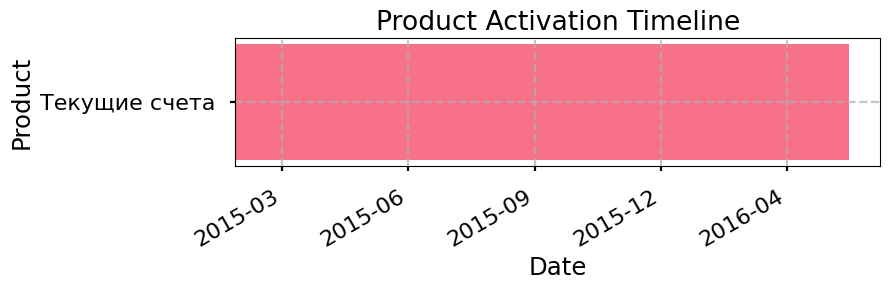

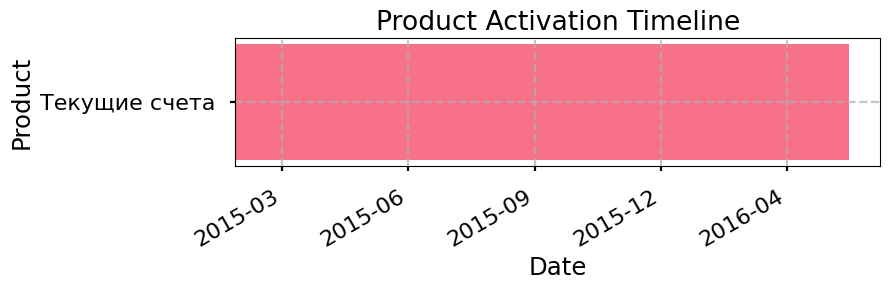

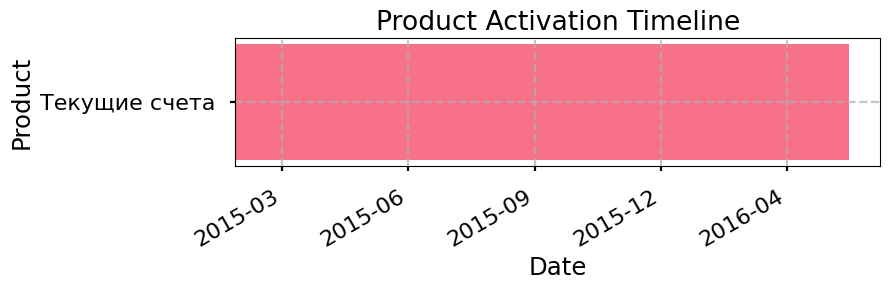

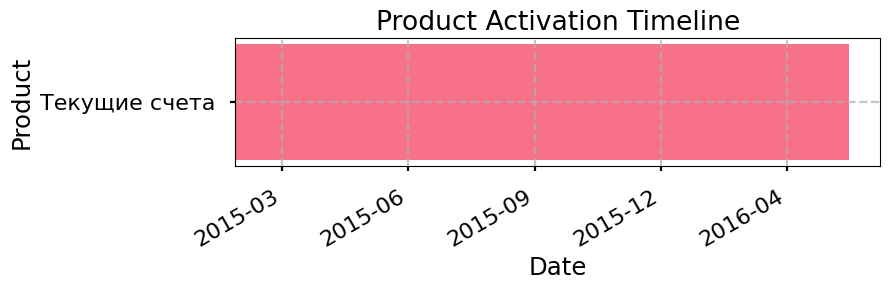

No active products to plot


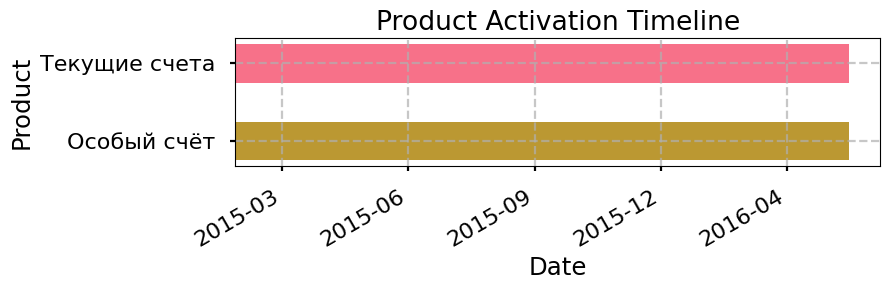

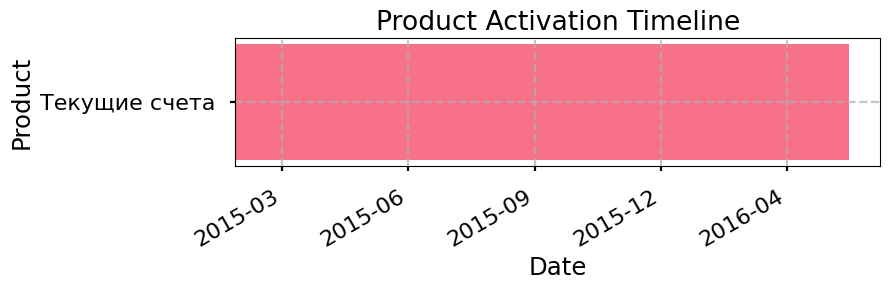

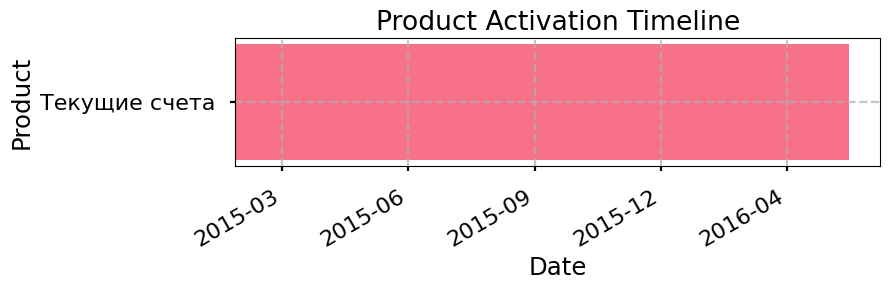

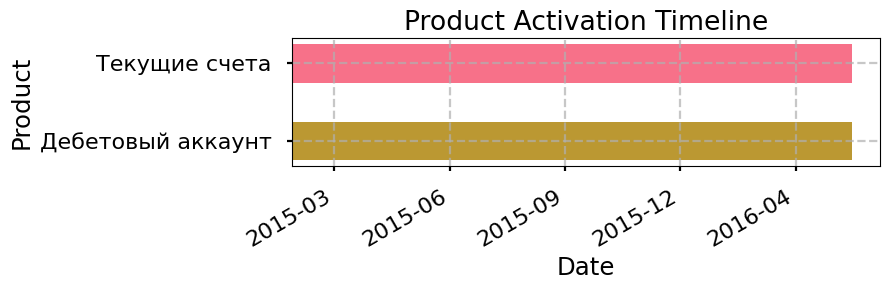

In [31]:
def get_active_periods(df, products):
    periods = []
    
    for product in products:
        active_dates = df[df[product] == 1]['fecha_dato']
        if not active_dates.empty:
            start = active_dates.min()
            end = active_dates.max()
            periods.append({
                'Product': cool_names_dict[product],
                'Start': start,
                'End': end
            })
    return pd.DataFrame(periods)

def plot_gantt(df, products):
    timeline_df = get_active_periods(df, products)
    
    if timeline_df.empty:
        print("No active products to plot")
        return
    
    fig, ax = plt.subplots(figsize=(9, 3))
    
    # Convert dates to matplotlib date format
    timeline_df['Start_num'] = mdates.date2num(timeline_df['Start'])
    timeline_df['End_num'] = mdates.date2num(timeline_df['End'])
    
    # Create bars for each product
    for i, (_, row) in enumerate(timeline_df.iterrows()):
        duration = row['End_num'] - row['Start_num']
        ax.barh(
            y=row['Product'],
            width=duration,
            left=row['Start_num'],
            height=0.5,
            align='center',
            label=row['Product']
        )
    
    # Format x-axis
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    
    # Format y-axis
    ax.set_yticks(timeline_df['Product'])
    ax.set_yticklabels(timeline_df['Product'])
    ax.invert_yaxis()  # reverse order
    
    # Add labels and title
    ax.set_xlabel('Date')
    ax.set_ylabel('Product')
    ax.set_title('Product Activation Timeline')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Auto format dates
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

# Посмотрим динамику обладания продуктами по 10 случайным людям
for id in df['ncodpers'].sample(10):
    one_man = df[df['ncodpers']==id]
    selected_data = one_man[['fecha_dato'] + products].copy()
    # Конвертация в datetime
    selected_data['fecha_dato'] = pd.to_datetime(selected_data['fecha_dato'])
    plot_gantt(selected_data, products)


В основном история выгляди так. У человека есть текущий счёт (ну или десткий) и с ним он живёт. Реже встречается большее продуктовое разнообразие. Покупка нового продукта - вооще исчезающий случай, но возможно наличие других признаков позволит всё-таки её спрогнозировать.

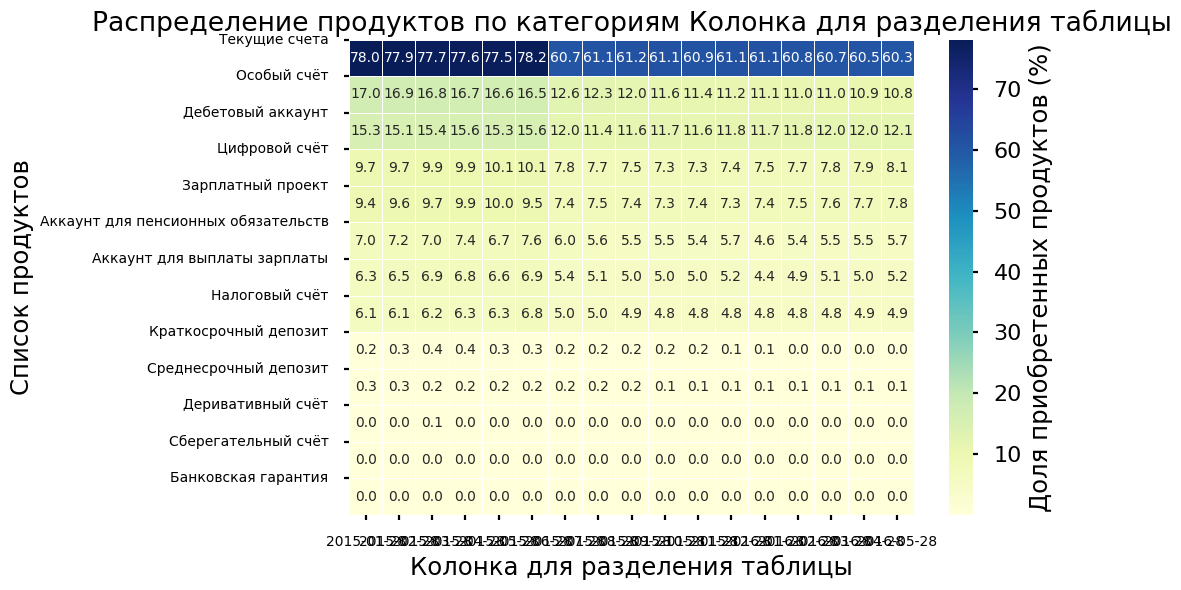

In [32]:
make_heatmap(df, f='fecha_dato', dict=cool_names_dict, products=products+outsiders)

Вот так выглядит общее потребление продуктов по выборке в целом. Прослеживается тренд на снижение доли текущих счетов в объей структуре продуктов.
Также снижается доля Особых счетов, а Сберегательный счёт и Банковская гарантия с Деривативным Счётом как никого не интересовали, так и не интересуют.  




# Анализ данных и рекомендации для системы рекомендаций

## Общий вывод

Анализ данных показывает, что набор данных в целом достаточно чистый с минимальными пропусками, но содержит несколько проблем, которые необходимо решить перед построением рекомендательной системы.

Основные наблюдения:
- 57.8% клиентов имеют минимальную активность
- Значительная доля клиентов пришла через 3 основных канала привлечения
- Наличие избытка малоинформативных признаков:
  - Статус занятости "N" у большинства клиентов
  - Категория "соотечественники"
  - Статус "супруг(а) работника"
  - Последняя дата премиума

## Рекомендации по построению рекомендательной системы

### Исправление выбросов и аномалий
- Удаление/коррекция клиентов с:
  - Возрастом 0 или >100 лет
  - Отрицательным стажем (замена на среднее значение)
  - Аномально высокими доходами

### Обработка пропусков
- Количественные признаки:
  - Заполнение средним/медианой/модой
- Категориальные признаки:
  - Использование наиболее частого значения
  - Создание категории "неизвестно"

### Оптимизация категорий
- Группировка продуктов с долей <1% в категорию "прочие"

### Удаление нефункциональных признаков
- Исключение малоинформативных параметров:
  - Статус занятости "N"
  - Категория "соотечественники"
  - Семейный статус "супруг(а) работника"
  - Дата последней премии

### Предобработка данных
- Нормализация:
  - Стаж клиента (в месяцах)
  - Доход домохозяйств

## Архитектура рекомендательной системы

### Подходы к реализации
1. **Коллаборативная фильтрация**
   - Использование паттернов поведения пользователей
   - Рекомендации на основе похожих пользователей

2. **Контентная фильтрация**
   - Анализ персональных предпочтений
   - Учет истории потребления за предыдущий год

3. **Гибридная система**
   - Комбинация коллаборативных и контентных методов
   - Повышение точности рекомендаций

4. **Анализ временных рядов**
   - Мониторинг трендов:
     - Снижение доли текущих счетов
     - Уменьшение особых счетов
   - Предложение альтернативных продуктов


In [33]:
formatted_markdown_content = """
# Анализ данных и рекомендации для системы рекомендаций

## Общий вывод

Анализ данных показывает, что набор данных в целом достаточно чистый с минимальными пропусками, но содержит несколько проблем, которые необходимо решить перед построением рекомендательной системы.

Основные наблюдения:
- 57.8% клиентов имеют минимальную активность
- Значительная доля клиентов пришла через 3 основных канала привлечения
- Наличие избытка малоинформативных признаков:
  - Статус занятости "N" у большинства клиентов
  - Категория "соотечественники"
  - Статус "супруг(а) работника"
  - Последняя дата премиума

## Рекомендации по построению рекомендательной системы

### Исправление выбросов и аномалий
- Удаление/коррекция клиентов с:
  - Возрастом 0 или >100 лет
  - Отрицательным стажем (замена на среднее значение)
  - Аномально высокими доходами

### Обработка пропусков
- Количественные признаки:
  - Заполнение средним/медианой/модой
- Категориальные признаки:
  - Использование наиболее частого значения
  - Создание категории "неизвестно"

### Оптимизация категорий
- Группировка продуктов с долей <1% в категорию "прочие"

### Удаление нефункциональных признаков
- Исключение малоинформативных параметров:
  - Статус занятости "N"
  - Категория "соотечественники"
  - Семейный статус "супруг(а) работника"
  - Дата последней премии

### Предобработка данных
- Нормализация:
  - Стаж клиента (в месяцах)
  - Доход домохозяйств

## Архитектура рекомендательной системы

### Подходы к реализации
1. **Коллаборативная фильтрация**
   - Использование паттернов поведения пользователей
   - Рекомендации на основе похожих пользователей

2. **Контентная фильтрация**
   - Анализ персональных предпочтений
   - Учет истории потребления за предыдущий год

3. **Гибридная система**
   - Комбинация коллаборативных и контентных методов
   - Повышение точности рекомендаций

4. **Анализ временных рядов**
   - Мониторинг трендов:
     - Снижение доли текущих счетов
     - Уменьшение особых счетов
   - Предложение альтернативных продуктов

"""


In [36]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "Bank_product_Analysis"
RUN_NAME = "eda"

FS_ASSETS = 'analysis'
os.makedirs(FS_ASSETS, exist_ok=True)

# Локальный tracking-сервер MLflow
mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

mlflow.set_experiment(EXPERIMENT_NAME)

2026/09/15 14:21:39 INFO mlflow.tracking.fluent: Experiment with name 'Bank_product_Analysis' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/Admin/mlruns_artifacts/1', creation_time=1789471299230, experiment_id='1', last_update_time=1789471299230, lifecycle_stage='active', name='Bank_product_Analysis', tags={}>

In [37]:
with mlflow.start_run():
    with open("recommendations_analysis.md", "w", encoding="utf-8") as f:
        f.write(formatted_markdown_content)

    mlflow.log_artifact("recommendations_analysis.md", artifact_path=FS_ASSETS)

🏃 View run illustrious-bass-267 at: http://127.0.0.1:5000/#/experiments/1/runs/82974028f65c477d87b6831b7aa40679
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Теперь результаты анализа залогированы в ML-flow.